# Game Theory - Price war in Duopoly market

Application of Game Theory concepts to a duopoly market betwwen food delivery firms, Meituan and Ele.me. 

Using simulation to find witch strategy is best.

## 1.Simulation: Cooperate in first round by Actor A (Meituan) followed by Tit-for-That strategy, while Actor B (Ele.me) always defect

### Overview

In this scenario,
- Ele.me wants to maximize it's payoff by always defecting
- Meituan tries to cooperate at first (in round 1), after that Meituan will take decisions following the simple rule of imitating whatever strategy Ele.me have chosen previously. Hence, if Ele.me defect Meituan will defect, while if Ele.me cooperate than Meituan will cooperate. Therefore, Meituan follows a Tit-for-Tat strategy.

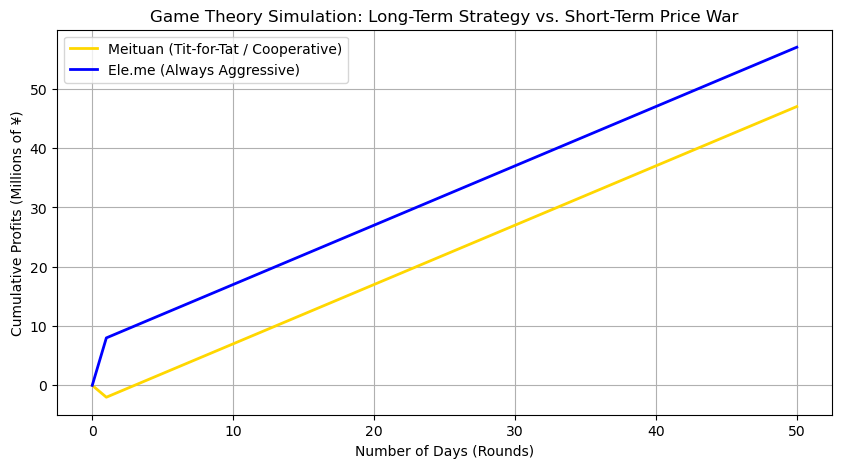

Total Profit Meituan: 47 M¥
Total Profit Ele.me: 57 M¥


In [9]:
import random
import matplotlib.pyplot as plt

# Definition of the game rules
# Payoff Matrix = (Meituan_Gain, Eleme_Gain)
PAYOFFS = {
    ("Cooperate", "Cooperate"): (5, 5),
    ("Cooperate", "Defect"): (-2, 8),
    ("Defect", "Cooperate"): (8, -2),
    ("Defect", "Defect"): (1, 1),
}


# Strategies 
def strategy_tit_for_tat(opponent_history):
    if not opponent_history:
        return "Cooperate"
    return opponent_history[-1]


def strategy_always_aggressive():
    return "Defect"


# Simulation of 50 rounds (1 round = 1 day)
ROUNDS = 50
history_meituan = []
history_eleme = []

cumulative_scores_meituan = [0]
cumulative_scores_eleme = [0]

for r in range(ROUNDS):
    action_meituan = strategy_tit_for_tat(history_eleme)
    action_eleme = strategy_always_aggressive()

    # Saving choices into history
    history_meituan.append(action_meituan)
    history_eleme.append(action_eleme)

    # Calculating round gains
    gain_m, gain_e = PAYOFFS[(action_meituan, action_eleme)]

    # Updating scores
    cumulative_scores_meituan.append(cumulative_scores_meituan[-1] + gain_m)
    cumulative_scores_eleme.append(cumulative_scores_eleme[-1] + gain_e)

# Plot and Result
plt.figure(figsize=(10, 5))
plt.plot(
    cumulative_scores_meituan,
    label="Meituan (Tit-for-Tat / Cooperative)",
    color="gold",
    linewidth=2,
)
plt.plot(
    cumulative_scores_eleme,
    label="Ele.me (Always Aggressive)",
    color="blue",
    linewidth=2,
)
plt.title(
    "Game Theory Simulation: Long-Term Strategy vs. Short-Term Price War",
    fontsize=12,
)
plt.xlabel("Number of Days (Rounds)")
plt.ylabel("Cumulative Profits (Millions of ¥)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Total Profit Meituan: {cumulative_scores_meituan[-1]} M¥")
print(f"Total Profit Ele.me: {cumulative_scores_eleme[-1]} M¥")


### Results

After fifty days, we can clearly obeserved that Meituan strategy in this situation deserve the firm because Ele.me always defect, hence Ele.me earns 8 million of yuan, while Meituan loose 2 million of yuan.
After the first day until the end of the rounds, both firms will play defect earning 1 million od yuan for each rounds.

## 2. Stratregy : Ele.me plays first and is always cooperative while Meituan plays a Tit-for-That strategy

## Overview

Situation where each players always cooperate.

Detail :
- The first player playing chose to always cooperate
- The second player chose to follow a tic-for-that strategy
- This situation create a positive circle, resluting in an always cooperative states.

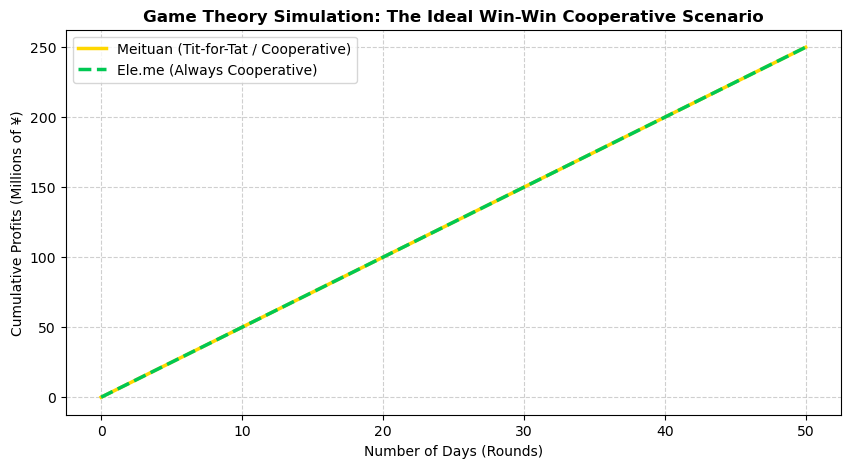

Final Profit Meituan (Tit-for-Tat) : 250 M¥
Final Profit Ele.me (Cooperative)  : 250 M¥
Total Market Value Generated       : 500 M¥


In [16]:
import matplotlib.pyplot as plt

# Definition of the Payoff Matrix
# Matrix=(Meituan_Gain, Eleme_Gain)
PAYOFFS = {
    ("Cooperate", "Cooperate"): (5, 5),
    ("Cooperate", "Defect"): (-2, 8),
    ("Defect", "Cooperate"): (8, -2),
    ("Defect", "Defect"): (1, 1),
}


# 2. Strategy
def strategy_tit_for_tat(opponent_history):
    if not opponent_history:
        return "Cooperate"
    return opponent_history[-1]


def strategy_always_cooperative():
    return "Cooperate"


# Simulation of 50 rounds
ROUNDS = 50
history_meituan = []
history_eleme = []

# Starting charts at 0 profit
cumulative_scores_meituan = [0]
cumulative_scores_eleme = [0]

for r in range(ROUNDS):
    action_meituan = strategy_tit_for_tat(history_eleme)
    action_eleme = strategy_always_cooperative()

    # Saving choices into history
    history_meituan.append(action_meituan)
    history_eleme.append(action_eleme)

    # Calculating gains
    gain_m, gain_e = PAYOFFS[(action_meituan, action_eleme)]

    # Updating scores
    cumulative_scores_meituan.append(cumulative_scores_meituan[-1] + gain_m)
    cumulative_scores_eleme.append(cumulative_scores_eleme[-1] + gain_e)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    cumulative_scores_meituan,
    label="Meituan (Tit-for-Tat / Cooperative)",
    color="gold",
    linewidth=2.5,
)
plt.plot(
    cumulative_scores_eleme,
    label="Ele.me (Always Cooperative)",
    color="#00C853",  
    linewidth=2.5,
    linestyle="--",
)
plt.title(
    "Game Theory Simulation: The Ideal Win-Win Cooperative Scenario",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Days (Rounds)")
plt.ylabel("Cumulative Profits (Millions of ¥)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Results
final_meituan = cumulative_scores_meituan[-1]
final_eleme = cumulative_scores_eleme[-1]
total_market_value = final_meituan + final_eleme

print(f"Final Profit Meituan (Tit-for-Tat) : {final_meituan} M¥")
print(f"Final Profit Ele.me (Cooperative)  : {final_eleme} M¥")
print(f"Total Market Value Generated       : {total_market_value} M¥")


## 3. Strategy : Ele.me plays first and defect followed by a Tit-for That strategy, while Meituan plays Cooperate in first round followed by a Tit-for That strategy

### Overview

- the first player (Meituan) choses to cooperate in round 1, while the second player (Ele.me) choses to defect in round 1, after that he will follow a tit-for-that strategy for all the following rounds
- from round 2, Meituan will follow a Tit-for-That strategy

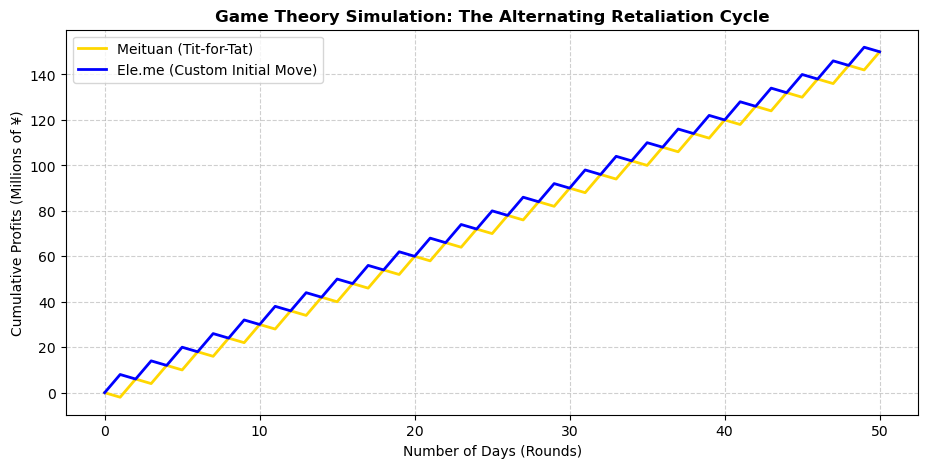

Final Profit Meituan (Tit-for-Tat) : 150 M¥
Final Profit Ele.me (Cooperative)  : 150 M¥
Total Market Value Generated       : 300 M¥


In [18]:
import matplotlib.pyplot as plt

# Definition of the rules
PAYOFFS = {
    ("Cooperate", "Cooperate"): (5, 5),
    ("Cooperate", "Defect"): (-2, 8),
    ("Defect", "Cooperate"): (8, -2),
    ("Defect", "Defect"): (1, 1),
}


# Strategies
def strategy_tit_for_tat(opponent_history):
    """Cooperates from round 1."""
    if not opponent_history:
        return "Cooperate"
    return opponent_history[-1]


def strategy_eleme_custom(current_round, opponent_history):
    """Defects on round 1, and follows a tit-for-that strategy from round 2"""
    if current_round == 0:
        return "Defect"
    if current_round == 1:
        return "Cooperate"
    return opponent_history[-1]


# Simulation of 50 rounds
ROUNDS = 50
history_meituan = []
history_eleme = []

cumulative_scores_meituan = [0]
cumulative_scores_eleme = [0]

for r in range(ROUNDS):
    action_meituan = strategy_tit_for_tat(history_eleme)
    action_eleme = strategy_eleme_custom(r, history_meituan)

    history_meituan.append(action_meituan)
    history_eleme.append(action_eleme)

    gain_m, gain_e = PAYOFFS[(action_meituan, action_eleme)]

    cumulative_scores_meituan.append(cumulative_scores_meituan[-1] + gain_m)
    cumulative_scores_eleme.append(cumulative_scores_eleme[-1] + gain_e)

# Plot
plt.figure(figsize=(11, 5))
plt.plot(
    cumulative_scores_meituan,
    label="Meituan (Tit-for-Tat)",
    color="gold",
    linewidth=2,
)
plt.plot(
    cumulative_scores_eleme,
    label="Ele.me (Custom Initial Move)",
    color="blue",
    linewidth=2,
)
plt.title(
    "Game Theory Simulation: The Alternating Retaliation Cycle",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Number of Days (Rounds)")
plt.ylabel("Cumulative Profits (Millions of ¥)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Results
final_meituan = cumulative_scores_meituan[-1]
final_eleme = cumulative_scores_eleme[-1]
total_market_value = final_meituan + final_eleme

print(f"Final Profit Meituan (Tit-for-Tat) : {final_meituan} M¥")
print(f"Final Profit Ele.me (Cooperative)  : {final_eleme} M¥")
print(f"Total Market Value Generated       : {total_market_value} M¥")


## Conclusion

The best scenario corresponds to a situation where both Players chose to cooperate. Resulting in the greatest total market value and the best payoff for each firm (equal payoff which maximize their profit). 

The worst scenario correponds to the situation where one of the Player decide to always defect shattering the confidence of the other Player which will take for action to defect after the first day. Resulting in the worst total market value, as well as lowest and inequal payoff between Players.

The scenario where in round 1, each players choose to play an opposite strategy followed by a Tit-for-that stratgey creates an echo. This results in an fluctuating market.